# Clustering-Based Course Recommenders

Users are grouped by the genres of the courses they have taken. Each user is then recommended the courses that are most
popular within their cluster and that they have not taken yet.

Cluster hyperparameters are chosen with unsupervised criteria (elbow, silhouette score) on the training data. The
recommendations are then scored by HitRate@10 and NDCG@10 on the shared leave-one-out test split, like every other family.

In [1]:
%matplotlib inline

import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sys.path.append("..")
from recsys import data, evaluation, results, splits

SEED = splits.SEED

## User profiles

A user's profile counts how many of their training courses belong to each genre.
Profiles are built from the training enrolments only, so the held-out test course never influences a user's cluster.
The first version used a pre-computed profile file built from each user's full history.

In [2]:
ratings = data.load_ratings()
index = data.Index(ratings)
train_loo, test_loo = splits.leave_one_out(ratings)

genres = data.load_course_genres().set_index("COURSE_ID").loc[index.items]
genre_names = list(genres.columns.drop("TITLE"))
genre_features = genres[genre_names].to_numpy(dtype=float)

train_matrix = splits.interaction_matrix(train_loo, index)
profiles = pd.DataFrame(train_matrix @ genre_features, columns=genre_names, index=index.users)

print(f"Profiles: {profiles.shape[0]:,} users x {profiles.shape[1]} genres")
profiles.describe().round(2)

Profiles: 33,901 users x 14 genres


,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,33901.00,33901.00,33901.00,33901.00,33901.00,33901.00,33901.00,33901.00,33901.00,33901.00,33901.00,33901.00,33901.00,33901.00
mean,1.65,1.03,0.72,1.09,0.29,0.93,0.00,1.52,1.42,0.15,0.31,0.68,0.09,0.30
std,2.38,1.29,1.19,1.51,0.72,1.46,0.02,1.62,2.24,0.37,0.74,1.35,0.42,0.62
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,2.00,2.00,1.00,2.00,0.00,1.00,0.00,2.00,2.00,0.00,0.00,1.00,0.00,0.00
max,21.00,6.00,13.00,16.00,5.00,15.00,1.00,11.00,18.00,2.00,7.00,18.00,5.00,4.00


Genre counts are on very different scales, so they are standardised before clustering.

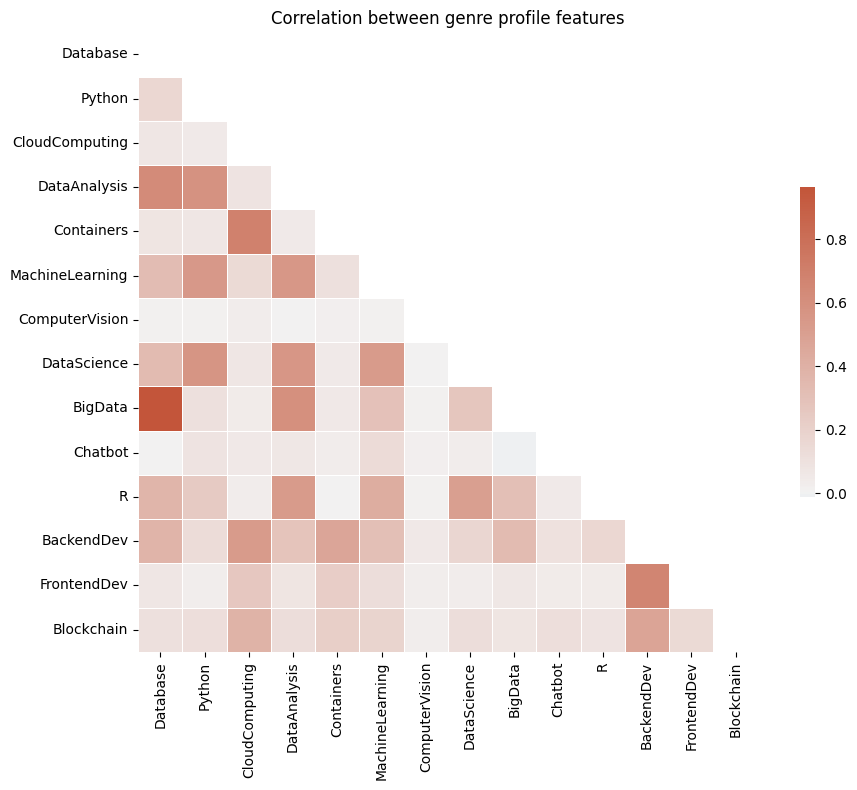

In [3]:
features = StandardScaler().fit_transform(profiles)

plt.figure(figsize=(10, 8))
corr = pd.DataFrame(features, columns=genre_names).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(230, 20, as_cmap=True), center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.5})
plt.title("Correlation between genre profile features")
plt.tight_layout()
plt.show()

## K-Means

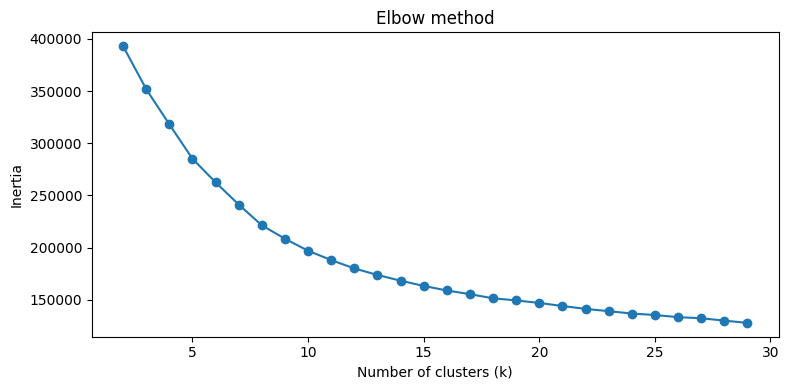

In [4]:
k_values = range(2, 30)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(features).inertia_ for k in k_values]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, "o-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.tight_layout()
plt.show()

The curve flattens gradually with no sharp elbow. k = 20 is used, as in the original analysis.

In [5]:
labels = {}
kmeans = KMeans(n_clusters=20, n_init=20, random_state=SEED).fit(features)
labels["KMeans"] = kmeans.labels_

### K-Means on PCA components
PCA keeps the components that explain at least 90% of the variance, and K-Means is fitted on those components.

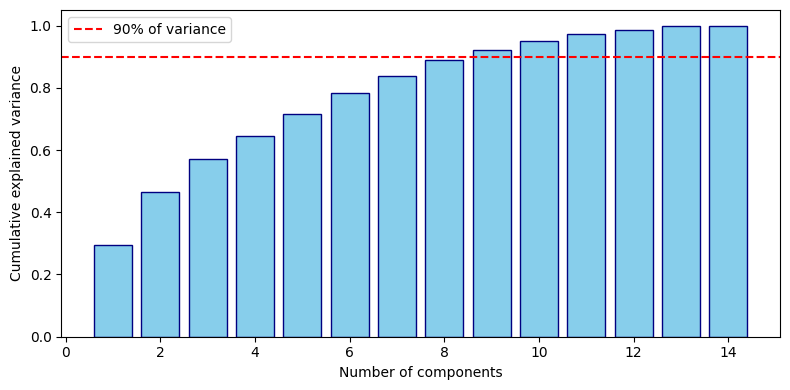

Components kept: 9 (92.3% of variance)


In [6]:
pca = PCA(random_state=SEED).fit(features)
cumulative = np.cumsum(pca.explained_variance_ratio_)
n_components = int(np.searchsorted(cumulative, 0.9) + 1)

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(cumulative) + 1), cumulative, color="skyblue", edgecolor="navy")
plt.axhline(0.9, color="r", linestyle="--", label="90% of variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.show()

pca_features = PCA(n_components=n_components, random_state=SEED).fit_transform(features)
labels["KMeans on PCA"] = KMeans(n_clusters=20, n_init=20, random_state=SEED).fit_predict(pca_features)
print(f"Components kept: {n_components} ({cumulative[n_components - 1]:.1%} of variance)")

## DBSCAN
DBSCAN finds the number of clusters itself and labels outliers as noise (-1). `min_samples` is chosen by silhouette score,
computed on a random sample of 10,000 users to keep it fast. Noise users are recommended the overall most popular courses.

In [7]:
def sampled_silhouette(x, cluster_labels):
    if len(np.unique(cluster_labels)) < 2:
        return -1.0
    return silhouette_score(x, cluster_labels, sample_size=10_000, random_state=SEED)


dbscan_scores = {}
for min_samples in range(15, 20):
    dbscan_labels = DBSCAN(eps=2, min_samples=min_samples).fit_predict(features)
    dbscan_scores[min_samples] = (sampled_silhouette(features, dbscan_labels), dbscan_labels)
    print(f"min_samples {min_samples}: silhouette {dbscan_scores[min_samples][0]:.4f}, "
          f"clusters {dbscan_labels.max() + 1}, noise users {(dbscan_labels == -1).sum():,}")

best_min_samples = max(dbscan_scores, key=lambda m: dbscan_scores[m][0])
labels["DBSCAN"] = dbscan_scores[best_min_samples][1]
print(f"Selected min_samples = {best_min_samples}")

min_samples 15: silhouette 0.1729, clusters 7, noise users 2,578


min_samples 16: silhouette 0.1884, clusters 6, noise users 2,622


min_samples 17: silhouette 0.1855, clusters 6, noise users 2,675


min_samples 18: silhouette 0.1855, clusters 6, noise users 2,697


min_samples 19: silhouette 0.1840, clusters 6, noise users 2,742
Selected min_samples = 16


## Hierarchical Agglomerative Clustering
Three linkage and distance combinations. Each tree is built once and then cut at every candidate number of clusters,
which gives the same result as refitting for each k. The number of clusters is chosen by silhouette score.

In [8]:
hac_configs = {
    "HAC Ward-Euclidean": ("ward", "euclidean"),
    "HAC Complete-Cosine": ("complete", "cosine"),
    "HAC Average-Manhattan": ("average", "cityblock"),
}

for name, (method, metric) in hac_configs.items():
    tree = linkage(features, method=method, metric=metric)
    scores = {}
    for n_clusters in range(10, 30):
        cut = fcluster(tree, t=n_clusters, criterion="maxclust") - 1
        scores[n_clusters] = (sampled_silhouette(features, cut), cut)
    best = max(scores, key=lambda k: scores[k][0])
    labels[name] = scores[best][1]
    print(f"{name}: {best} clusters, silhouette {scores[best][0]:.4f}")
    del tree

HAC Ward-Euclidean: 27 clusters, silhouette 0.1904


HAC Complete-Cosine: 17 clusters, silhouette 0.1052


HAC Average-Manhattan: 10 clusters, silhouette 0.5583


## Cluster quality
Silhouette (higher is better), Calinski-Harabasz (higher is better) and Davies-Bouldin (lower is better).
The largest cluster share shows whether one cluster swallows most users, which makes its recommendations close to plain popularity.

In [9]:
quality = []
for name, cluster_labels in labels.items():
    clustered = cluster_labels >= 0
    counts = np.bincount(cluster_labels[clustered])
    quality.append({
        "model": name,
        "clusters": len(counts),
        "silhouette": sampled_silhouette(features[clustered], cluster_labels[clustered]),
        "calinski_harabasz": calinski_harabasz_score(features[clustered], cluster_labels[clustered]),
        "davies_bouldin": davies_bouldin_score(features[clustered], cluster_labels[clustered]),
        "largest_cluster_share": counts.max() / len(cluster_labels),
    })
pd.DataFrame(quality).round(3)

,model,clusters,silhouette,calinski_harabasz,davies_bouldin,largest_cluster_share
0,KMeans,20,0.244,4008.524,1.486,0.222
1,KMeans on PCA,20,0.229,3971.975,1.505,0.219
2,DBSCAN,6,0.221,1441.204,1.493,0.772
3,HAC Ward-Euclidean,27,0.190,2655.455,1.756,0.189
4,HAC Complete-Cosine,17,0.105,1792.369,1.966,0.197
5,HAC Average-Manhattan,10,0.558,978.121,1.189,0.978


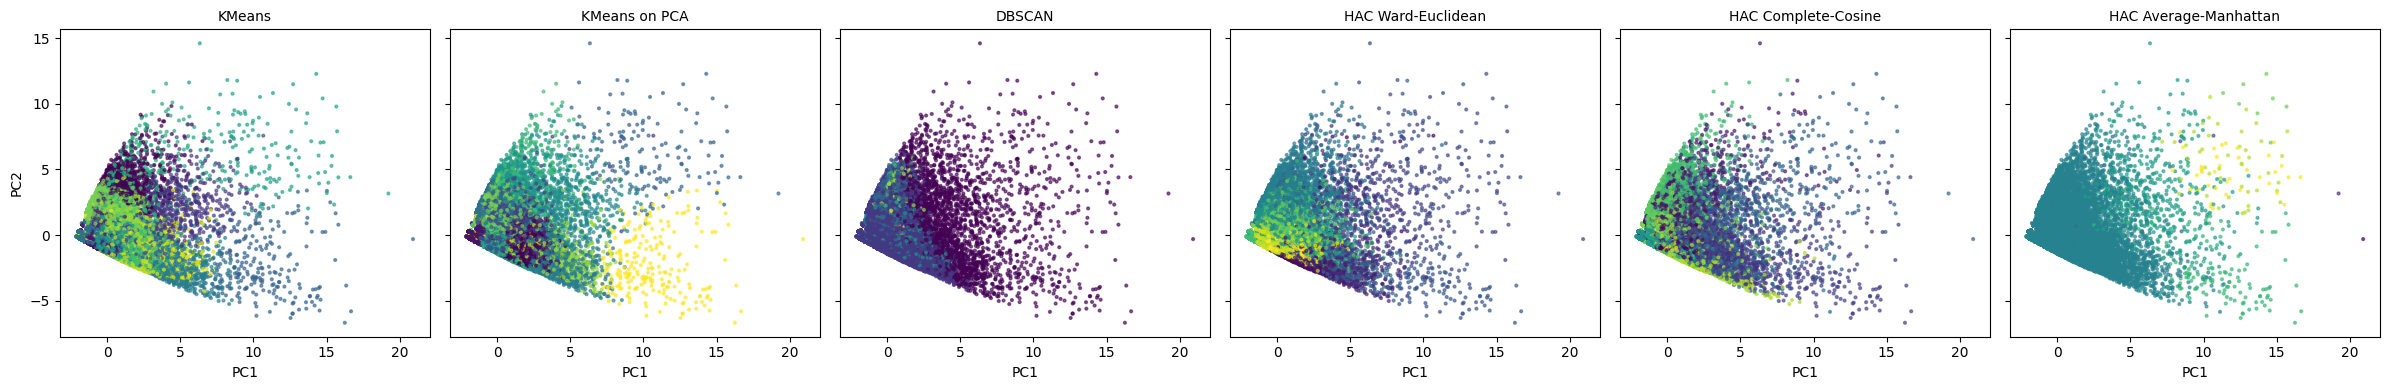

In [10]:
coords = PCA(n_components=2, random_state=SEED).fit_transform(features)
fig, axes = plt.subplots(1, len(labels), figsize=(4 * len(labels), 4), sharex=True, sharey=True)
for ax, (name, cluster_labels) in zip(axes, labels.items()):
    ax.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap="viridis", s=4, alpha=0.6)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.tight_layout()
plt.show()

## Recommendations
Each unseen course is scored by how many training enrolments it has among the user's cluster. Cluster labels are
aligned with `index.users`, so each label belongs to the right user. The first version of this step used the
DataFrame row position as the user id, which matched real user ids for only 200 users.

In [11]:
def cluster_popularity(cluster_labels):
    popularity = np.asarray(train_matrix.sum(axis=0)).ravel()
    clustered = cluster_labels >= 0
    membership = sp.csr_matrix(
        (np.ones(clustered.sum()), (np.flatnonzero(clustered), cluster_labels[clustered])),
        shape=(index.n_users, cluster_labels.max() + 1),
    )
    cluster_counts = np.asarray((membership.T @ train_matrix).todense())

    def score(matrix, users):
        user_labels = cluster_labels[users]
        scores = np.tile(popularity, (len(users), 1)).astype(float)
        has_cluster = user_labels >= 0
        scores[has_cluster] = cluster_counts[user_labels[has_cluster]]
        return scores

    return score

Example: top 5 recommendations from K-Means for one test user.

In [12]:
user_row = index.user_to_idx.loc[test_loo["user"].iloc[0]]
taken = train_matrix[user_row].toarray().ravel() > 0
example_scores = cluster_popularity(labels["KMeans"])(train_matrix, np.array([user_row]))[0]
example_scores[taken] = -np.inf
top = np.argsort(-example_scores)[:5]

print(f"User {index.users[user_row]} took {taken.sum()} training courses, K-Means cluster {labels['KMeans'][user_row]}")
for rank, item in enumerate(top, start=1):
    print(f"{rank}. {genres.index[item]}: {genres['TITLE'].iloc[item].strip()}")

User 2 took 60 training courses, K-Means cluster 6
1. BD0115EN: mapreduce and yarn
2. DS0101EN: introduction to data science
3. DS0105EN: data science hands on with open source tools
4. ML0151EN: machine learning with r
5. DB0151EN: nosql and dbaas 101


## Test results

In [13]:
ranking_rows = []
for name, cluster_labels in labels.items():
    scores = evaluation.evaluate_ranking(cluster_popularity(cluster_labels), train_loo, test_loo, index)
    ranking_rows.append({"family": "Clustering", "model": name, **scores})

pd.DataFrame(ranking_rows).sort_values("ndcg@10", ascending=False).round(4)

,family,model,hit_rate@10,ndcg@10
3,Clustering,HAC Ward-Euclidean,0.6735,0.4305
0,Clustering,KMeans,0.6662,0.4260
1,Clustering,KMeans on PCA,0.6653,0.4222
4,Clustering,HAC Complete-Cosine,0.6561,0.4087
2,Clustering,DBSCAN,0.5895,0.3531
5,Clustering,HAC Average-Manhattan,0.5760,0.3422


In [14]:
results.save(ranking_rows, "ranking", source="clustering");

The comparison with the popularity baseline and the other families is in `model_comparison.ipynb`.
Better cluster-quality scores do not necessarily mean better recommendations: a configuration with one dominant cluster
can score well on silhouette while its recommendations are close to plain popularity.